<a href="https://colab.research.google.com/github/narayaniiii/PID-AutoTuning-GUI/blob/main/yoloandrf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Install YOLOv8
!pip install ultralytics -q

import os, zipfile, cv2
import numpy as np
from ultralytics import YOLO
print("✅ All installed!")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 66.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ All installed!


In [ ]:
import os
for f in os.listdir('/content/drive/MyDrive'):
    if f.endswith('.zip'):
        print(repr(f))

'PE (5).zip'
'ABS (2).zip'
'Nylon (2) (1).zip'
'PET.zip'
'PS.zip'
'PVC.zip'


In [ ]:
zip_files = {
    'PE (5).zip':          'PE',
    'PVC.zip':             'PVC',
    'PS.zip':              'PS',
    'Nylon (2) (1).zip':       'Nylon',
    'ABS (2).zip':         'ABS',
    'PET.zip':             'PET',
}

drive_path = '/content/drive/MyDrive/'
extract_base = '/content/raw_images/'
os.makedirs(extract_base, exist_ok=True)

for zip_name, class_name in zip_files.items():
    zip_path = drive_path + zip_name
    out_path = extract_base + class_name
    os.makedirs(out_path, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(out_path)
    # Flatten: move all jpgs to class folder root
    for root, dirs, files in os.walk(out_path):
        for f in files:
            if f.lower().endswith(('.jpg','.jpeg','.png')):
                src = os.path.join(root, f)
                dst = os.path.join(out_path, f)
                if src != dst:
                    os.rename(src, dst)
    count = len([f for f in os.listdir(out_path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
    print(f"✅ {class_name}: {count} images")

✅ PE: 88 images
✅ PVC: 153 images
✅ PS: 167 images
✅ Nylon: 40 images
✅ ABS: 55 images
✅ PET: 88 images


In [ ]:
from scipy import ndimage
import random

classes = ['ABS', 'Nylon', 'PE', 'PET', 'PS', 'PVC']  # 6 classes

dataset_path = '/content/yolo_dataset/'
for split in ['images/train', 'images/val', 'labels/train', 'labels/val']:
    os.makedirs(dataset_path + split, exist_ok=True)

def auto_annotate(img_path, class_id, out_img_dir, out_lbl_dir):
    img = cv2.imread(img_path)
    if img is None:
        return
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    # Threshold: find bright glowing particles on dark background
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)

    # Clean up noise
    kernel = np.ones((3,3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    thresh = cv2.dilate(thresh, kernel, iterations=2)

    # Find connected components (each = one particle)
    labeled, num_features = ndimage.label(thresh)
    annotations = []

    for i in range(1, num_features + 1):
        component = (labeled == i)
        rows = np.any(component, axis=1)
        cols = np.any(component, axis=0)
        rmin, rmax = np.where(rows)[0][[0, -1]]
        cmin, cmax = np.where(cols)[0][[0, -1]]

        # Filter tiny noise (less than 20px wide or tall)
        if (rmax - rmin) < 20 or (cmax - cmin) < 20:
            continue

        # YOLO format: class cx cy w h (all normalized 0-1)
        cx = ((cmin + cmax) / 2) / w
        cy = ((rmin + rmax) / 2) / h
        bw = (cmax - cmin) / w
        bh = (rmax - rmin) / h
        annotations.append(f"{class_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")

    if not annotations:
        return

    # Save image + label
    fname = os.path.splitext(os.path.basename(img_path))[0]
    cv2.imwrite(os.path.join(out_img_dir, fname + '.jpg'), img)
    with open(os.path.join(out_lbl_dir, fname + '.txt'), 'w') as f:
        f.write('\n'.join(annotations))

# Process all 6 classes with 80/20 train/val split
random.seed(42)

for class_name in classes:
    class_id = classes.index(class_name)
    folder = f'/content/raw_images/{class_name}/'
    if not os.path.exists(folder):
        print(f"⚠️ Skipping {class_name} — folder not found")
        continue

    imgs = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(imgs)
    split_idx = int(len(imgs) * 0.8)
    train_imgs = imgs[:split_idx]
    val_imgs   = imgs[split_idx:]

    for f in train_imgs:
        auto_annotate(folder+f, class_id,
                      dataset_path+'images/train',
                      dataset_path+'labels/train')
    for f in val_imgs:
        auto_annotate(folder+f, class_id,
                      dataset_path+'images/val',
                      dataset_path+'labels/val')

    print(f"✅ {class_name} (id={class_id}): {len(train_imgs)} train, {len(val_imgs)} val")

print("\n🎉 All annotations done!")
print("Train images:", len(os.listdir(dataset_path+'images/train')))
print("Val images:",   len(os.listdir(dataset_path+'images/val')))

✅ ABS (id=0): 44 train, 11 val
✅ Nylon (id=1): 32 train, 8 val
✅ PE (id=2): 70 train, 18 val
✅ PET (id=3): 70 train, 18 val
✅ PS (id=4): 133 train, 34 val
✅ PVC (id=5): 122 train, 31 val

🎉 All annotations done!
Train images: 470
Val images: 119


In [ ]:
# Write dataset config file
yaml_content = """
path: /content/yolo_dataset
train: images/train
val: images/val

nc: 6
names: ['ABS', 'Nylon', 'PE', 'PET', 'PS', 'PVC']
"""
with open('/content/microplastics.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ Config written!")

# Train YOLOv8 — nano model (fastest, works well for small datasets)
model = YOLO('yolov8n.pt')

model.train(
    data='/content/microplastics.yaml',
    epochs=50,
    imgsz=640,
    batch=8,
    name='microplastics_yolo',
    augment=True,      # helps ABS(50) and Nylon(40) small classes
    patience=15,       # early stopping if no improvement
    verbose=True
)

print("✅ Training complete!")
print("Best model saved at: /content/runs/detect/microplastics_yolo/weights/best.pt")

✅ Config written!
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/microplastics.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=microplastics_yolo, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2185.6±653.4 MB/s, size: 64.6 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 119 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 119/119 41.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.5it/s 3.3s
                   all        119       1201      0.838      0.741      0.836      0.656
                   ABS         11         90      0.892      0.889      0.949      0.828
                 Nylon          8        110      0.848      0.427      0.621      0.368
                    PE         18        338      0.754      0.832       0.88      0.683
                   PET         18         43      0.783      0.628       0.72      0.544
                    PS         34        177    

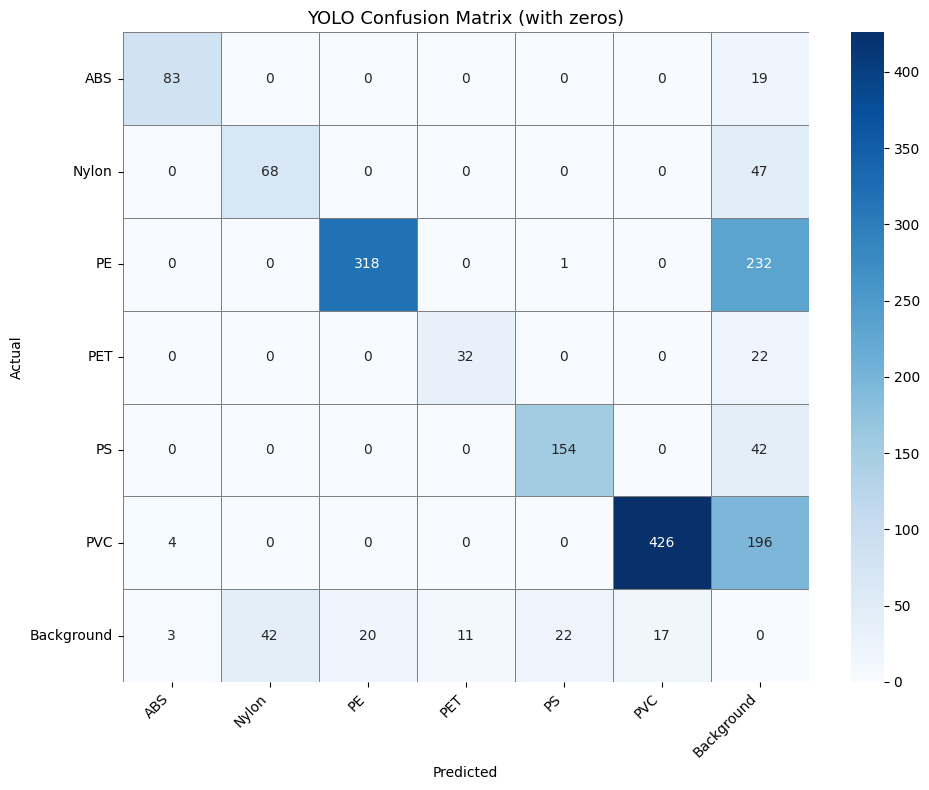

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import numpy as np
from ultralytics import YOLO

best_model = YOLO('/content/runs/detect/microplastics_yolo/weights/best.pt')
metrics = best_model.val(data='/content/microplastics.yaml')

print(f"\n✅ mAP@0.5:      {metrics.box.map50:.3f}")
print(f"✅ mAP@0.5:0.95: {metrics.box.map:.3f}")
print(f"✅ Precision:    {metrics.box.mp:.3f}")
print(f"✅ Recall:       {metrics.box.mr:.3f}")

# Get confusion matrix data directly from YOLO metrics
cm_array = metrics.confusion_matrix.matrix.astype(int)
classes_with_bg = ['ABS', 'Nylon', 'PE', 'PET', 'PS', 'PVC', 'Background']

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_array,
    annot=True,          # ← shows ALL numbers including zeros
    fmt='d',             # ← integer format
    cmap='Blues',
    xticklabels=classes_with_bg,
    yticklabels=classes_with_bg,
    linewidths=0.5,
    linecolor='gray'
)
plt.title('YOLO Confusion Matrix (with zeros)', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

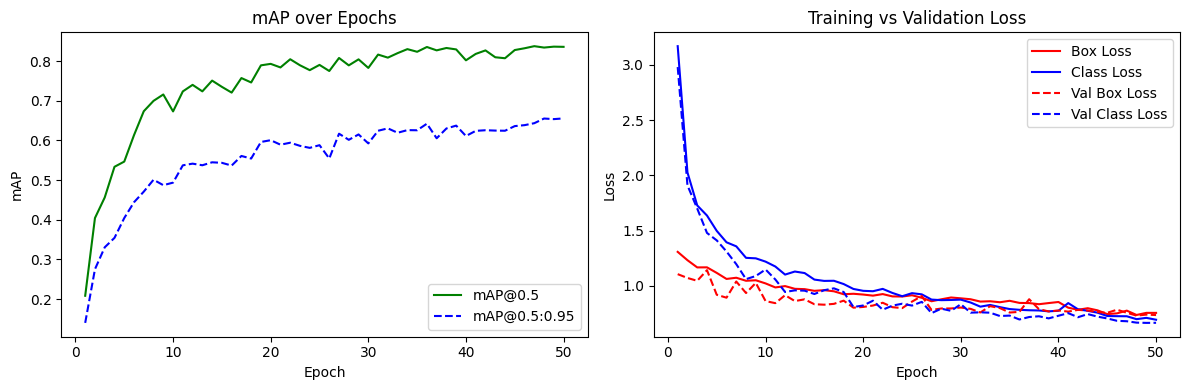

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load training results
results_csv = '/content/runs/detect/microplastics_yolo/results.csv'
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(df['epoch'], df['metrics/mAP50(B)'], 'g-', label='mAP@0.5')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], 'b--', label='mAP@0.5:0.95')
plt.title('mAP over Epochs')
plt.xlabel('Epoch')
plt.ylabel('mAP')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(df['epoch'], df['train/box_loss'], 'r-',  label='Box Loss')
plt.plot(df['epoch'], df['train/cls_loss'], 'b-',  label='Class Loss')
plt.plot(df['epoch'], df['val/box_loss'],   'r--', label='Val Box Loss')
plt.plot(df['epoch'], df['val/cls_loss'],   'b--', label='Val Class Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Feature structure from Excel: 36 features

Extracting features from image crops...

✅ Total crops: 7799
label
PE       2708
PVC      2276
PS       1054
Nylon     775
ABS       676
PET       310
Name: count, dtype: int64

=== RF Classification Report ===
              precision    recall  f1-score   support

         ABS       0.89      0.91      0.90       135
       Nylon       0.84      0.81      0.83       155
          PE       0.97      0.99      0.98       542
         PET       0.79      0.81      0.80        62
          PS       0.99      0.93      0.96       211
         PVC       0.95      0.95      0.95       455

    accuracy                           0.94      1560
   macro avg       0.91      0.90      0.90      1560
weighted avg       0.94      0.94      0.94      1560



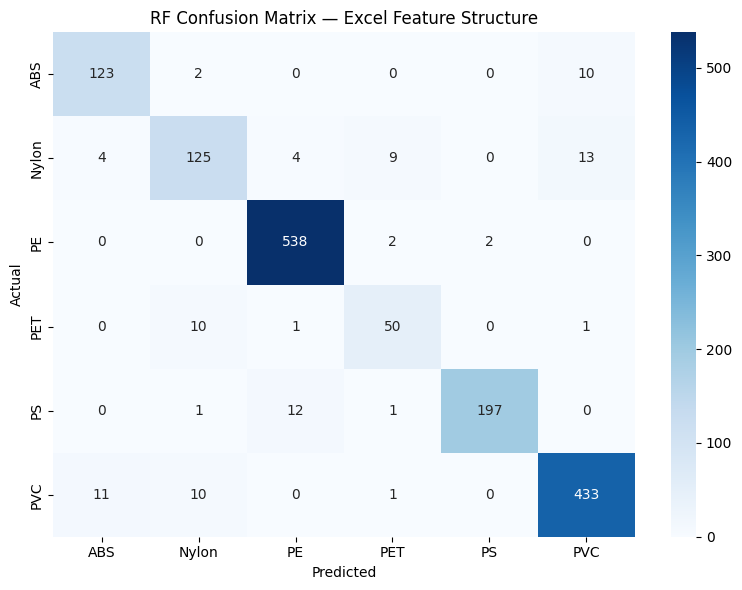

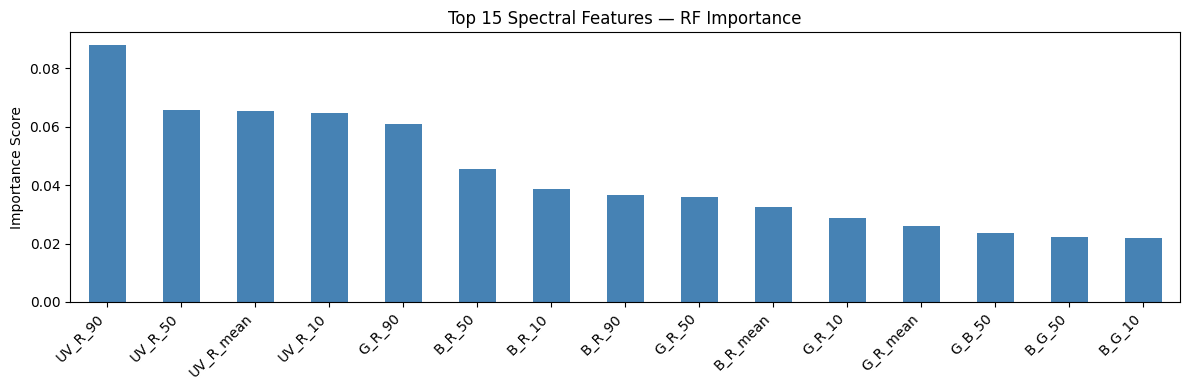


✅ RF trained! Classes: ['ABS' 'Nylon' 'PE' 'PET' 'PS' 'PVC']


In [ ]:
# Cell 7 — Train RF on image crops (labeled by folder)
# Excel sheet is used to define the feature structure

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import joblib, cv2, os
from scipy.signal import find_peaks
from ultralytics import YOLO

# Load Excel to get feature column structure
pim = pd.read_excel('/content/drive/MyDrive/RGB_datasets_updated.xlsx',
                    sheet_name='PIM_VLIZ')
excel_feature_cols = [c for c in pim.columns
                      if c not in ['Particle', 'Material']]
print(f"Feature structure from Excel: {len(excel_feature_cols)} features")

# Now extract same features from your actual image crops
classes = ['ABS', 'Nylon', 'PE', 'PET', 'PS', 'PVC']
raw_folder = '/content/raw_images/'
best_model = YOLO('/content/runs/detect/microplastics_yolo/weights/best.pt')

def extract_features_for_excel(crop):
    b_ch = crop[:, :, 0].astype(float)
    g_ch = crop[:, :, 1].astype(float)
    r_ch = crop[:, :, 2].astype(float)
    uv   = (0.5 * b_ch + 0.5 * g_ch)

    lighting = {'B': b_ch, 'G': g_ch, 'UV': uv}
    channels = {'R': r_ch, 'G': g_ch, 'B': b_ch}

    raw = {}
    for ln, lch in lighting.items():
        for cn, cch in channels.items():
            mask = lch > 10
            vals = cch[mask].flatten() if mask.sum() > 5 else cch.flatten()
            raw[f'{ln}_{cn}_10th'] = np.percentile(vals, 10)
            raw[f'{ln}_{cn}_50th'] = np.percentile(vals, 50)
            raw[f'{ln}_{cn}_90th'] = np.percentile(vals, 90)
            raw[f'{ln}_{cn}_mean'] = np.mean(vals)

    aligned = []
    for col in excel_feature_cols:
        matched = False
        for key, val in raw.items():
            if all(p in col for p in key.split('_')[:2]):
                aligned.append(val)
                matched = True
                break
        if not matched:
            aligned.append(0.0)
    return np.array(aligned).reshape(1, -1)

# Extract features from all training crops
crop_data = []
print("\nExtracting features from image crops...")

for class_name in classes:
    class_folder = raw_folder + class_name + '/'
    if not os.path.exists(class_folder):
        print(f"⚠️ Skipping {class_name}")
        continue

    imgs = [f for f in os.listdir(class_folder)
            if f.lower().endswith(('.jpg','.jpeg','.png'))]

    for fname in imgs:
        img_path = class_folder + fname
        img = cv2.imread(img_path)
        if img is None:
            continue

        results = best_model.predict(source=img_path,
                                     conf=0.25, verbose=False)
        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                pad = 5
                x1c = max(0, x1-pad); y1c = max(0, y1-pad)
                x2c = min(img.shape[1], x2+pad)
                y2c = min(img.shape[0], y2+pad)
                crop = img[y1c:y2c, x1c:x2c]

                if crop.size == 0 or crop.shape[0] < 10 or crop.shape[1] < 10:
                    continue

                feats = extract_features_for_excel(crop)[0]
                row = list(feats) + [class_name]
                crop_data.append(row)

df_crops = pd.DataFrame(crop_data,
                        columns=list(excel_feature_cols) + ['label'])
df_crops = df_crops.fillna(0)
print(f"\n✅ Total crops: {len(df_crops)}")
print(df_crops['label'].value_counts())

# Train RF on image crops using Excel feature structure
X_crop = df_crops[excel_feature_cols]
le_crop = LabelEncoder()
y_crop = le_crop.fit_transform(df_crops['label'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_crop)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y_crop,
    test_size=0.2, random_state=42, stratify=y_crop)

rf_crop = RandomForestClassifier(n_estimators=100, random_state=42)
rf_crop.fit(X_tr, y_tr)
y_pred = rf_crop.predict(X_te)

print("\n=== RF Classification Report ===")
print(classification_report(y_te, y_pred,
      target_names=le_crop.classes_))

# Confusion matrix
cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_crop.classes_,
            yticklabels=le_crop.classes_)
plt.title('RF Confusion Matrix — Excel Feature Structure')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Feature importance
importances = pd.Series(rf_crop.feature_importances_,
                        index=excel_feature_cols)
importances.sort_values(ascending=False).head(15).plot(
    kind='bar', figsize=(12, 4), color='steelblue')
plt.title('Top 15 Spectral Features — RF Importance')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\n✅ RF trained! Classes: {le_crop.classes_}")

In [ ]:
class_colors = {
    'ABS':   (255, 50,  50),
    'Nylon': (50,  255, 255),
    'PE':    (50,  255, 50),
    'PET':   (255, 255, 50),
    'PS':    (255, 50,  255),
    'PVC':   (50,  165, 255),
    'PP':    (200, 100, 50),
    'PUR':   (100, 50,  200),
}

best_model = YOLO('/content/runs/detect/microplastics_yolo/weights/best.pt')

def extract_features_for_excel(crop):
    b_ch = crop[:, :, 0].astype(float)
    g_ch = crop[:, :, 1].astype(float)
    r_ch = crop[:, :, 2].astype(float)
    uv   = (0.5 * b_ch + 0.5 * g_ch)

    lighting = {'B': b_ch, 'G': g_ch, 'UV': uv}
    channels = {'R': r_ch, 'G': g_ch, 'B': b_ch}

    raw = {}
    for ln, lch in lighting.items():
        for cn, cch in channels.items():
            mask = lch > 10
            vals = cch[mask].flatten() if mask.sum() > 5 else cch.flatten()
            raw[f'{ln}_{cn}_10th'] = np.percentile(vals, 10)
            raw[f'{ln}_{cn}_50th'] = np.percentile(vals, 50)
            raw[f'{ln}_{cn}_90th'] = np.percentile(vals, 90)
            raw[f'{ln}_{cn}_mean'] = np.mean(vals)

    aligned = []
    for col in excel_feature_cols:
        matched = False
        for key, val in raw.items():
            if all(p in col for p in key.split('_')[:2]):
                aligned.append(val)
                matched = True
                break
        if not matched:
            aligned.append(0.0)

    return np.array(aligned).reshape(1, -1)


def run_final_pipeline(img_path):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    display = img_rgb.copy()

    results = best_model.predict(source=img_path,
                                  conf=0.25, iou=0.45, verbose=False)
    class_counts = {}
    detection_log = []

    for r in results:
        for box in r.boxes:
            yolo_conf = float(box.conf)
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            pad = 5
            x1c = max(0, x1-pad); y1c = max(0, y1-pad)
            x2c = min(img.shape[1], x2+pad)
            y2c = min(img.shape[0], y2+pad)
            crop = img[y1c:y2c, x1c:x2c]

            if crop.size == 0 or crop.shape[0] < 10 or crop.shape[1] < 10:
                continue

            try:
                feats = extract_features_for_excel(crop)
                feats_scaled = scaler.transform(feats)
                rf_pred  = rf_crop.predict(feats_scaled)[0]
                rf_proba = rf_crop.predict_proba(feats_scaled).max()
                rf_class = le_crop.inverse_transform([rf_pred])[0]
            except:
                continue

            color = class_colors.get(rf_class, (200, 200, 200))
            label = f"{rf_class} {rf_proba:.2f}"
            cv2.rectangle(display, (x1, y1), (x2, y2), color, 2)
            (tw, th), _ = cv2.getTextSize(label,
                          cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            cv2.rectangle(display, (x1, y1-th-6),
                          (x1+tw+2, y1), color, -1)
            cv2.putText(display, label, (x1+1, y1-4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1)

            class_counts[rf_class] = class_counts.get(rf_class, 0) + 1
            detection_log.append({
                'RF_class':  rf_class,
                'RF_conf':   round(rf_proba, 3),
                'YOLO_conf': round(yolo_conf, 3),
            })

    return display, class_counts, pd.DataFrame(detection_log)

print("✅ Pipeline functions ready!")

✅ Pipeline functions ready!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

📍 PS (198).jpg | {'PS': 13}
📍 PS (111).jpg | {'PS': 4, 'PVC': 1}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

📍 PVC (465).jpg | {'PVC': 15, 'ABS': 3}
📍 PET (62).jpg | {'PET': 2}
📍 PE (275).jpg | {'PE': 2}
📍 PS (192).jpg | {'PS': 2}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


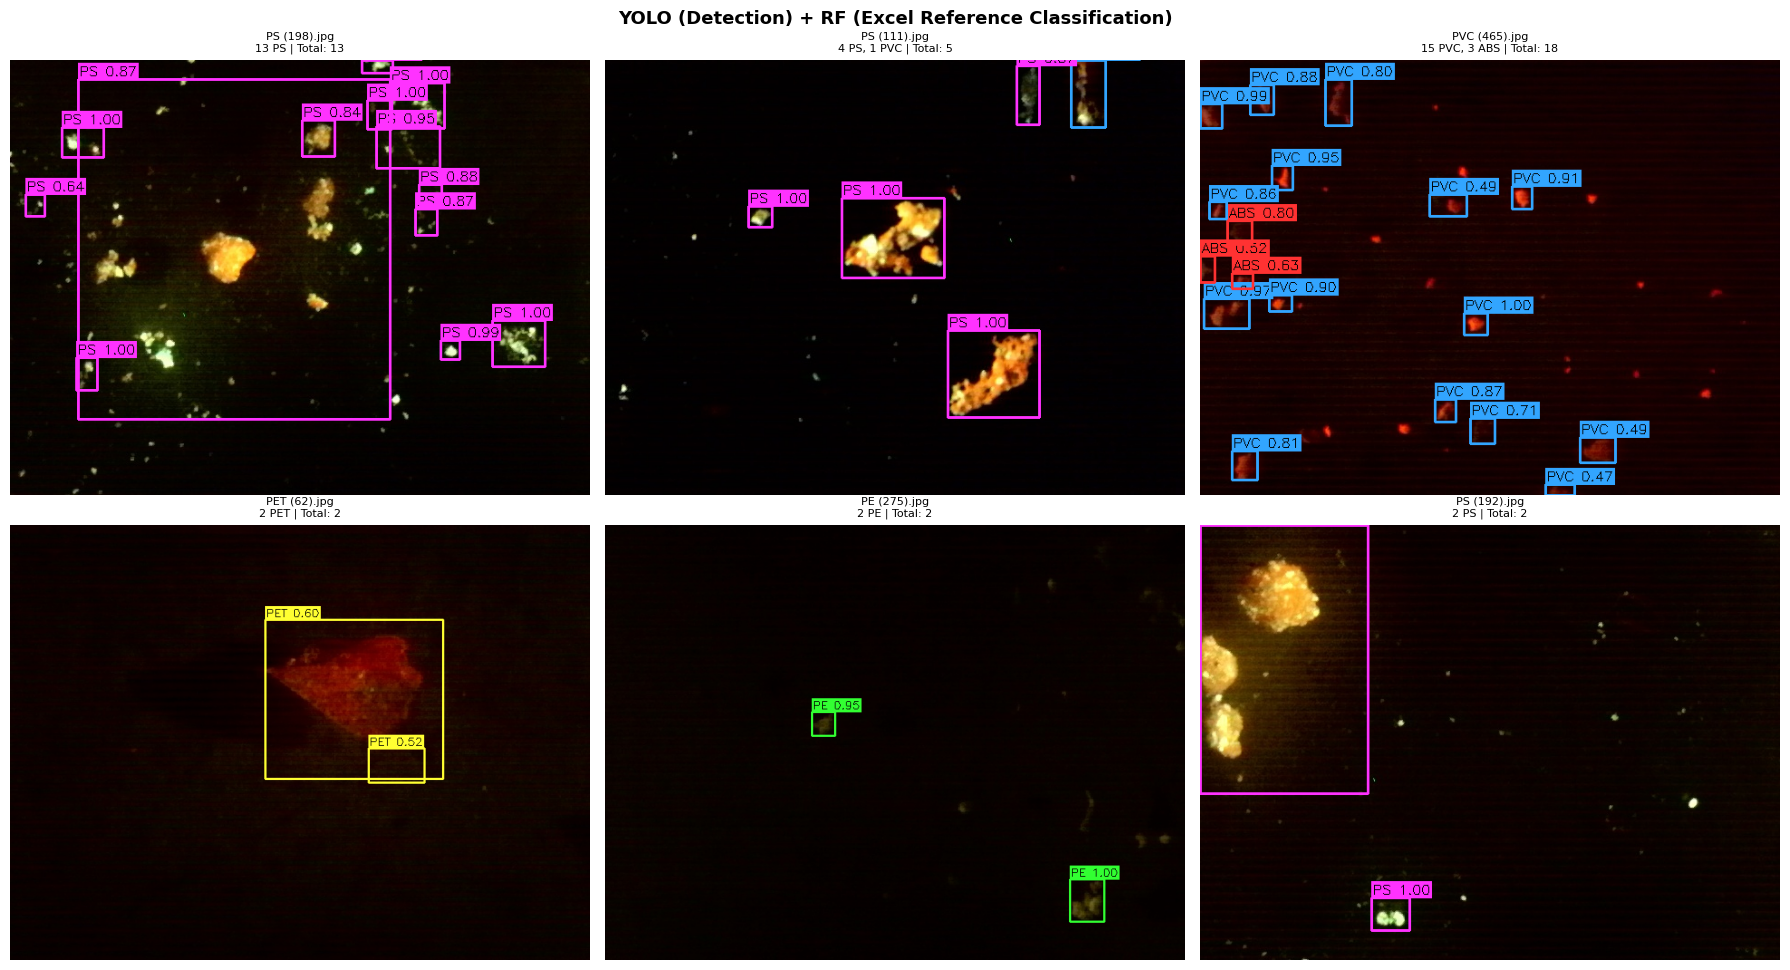

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

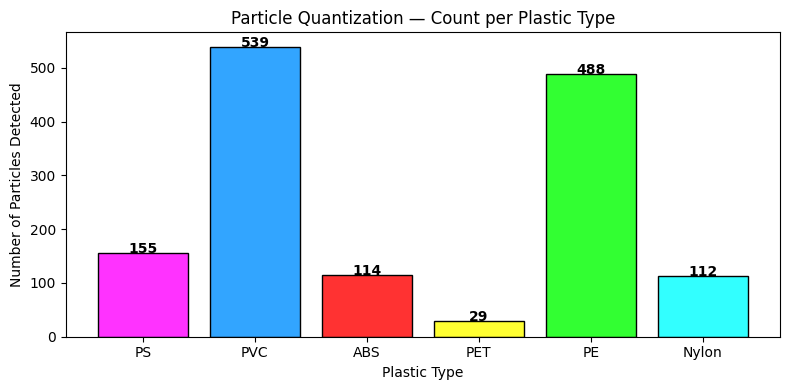

In [ ]:
val_folder = '/content/yolo_dataset/images/val/'
val_imgs = [f for f in os.listdir(val_folder)
            if f.endswith('.jpg')][:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, fname in enumerate(val_imgs):
    img_path = val_folder + fname
    output_img, counts, log = run_final_pipeline(img_path)
    summary = ', '.join([f"{v} {k}" for k,v in counts.items()])
    axes[idx].imshow(output_img)
    axes[idx].set_title(
        f"{fname}\n{summary} | Total: {sum(counts.values())}",
        fontsize=8)
    axes[idx].axis('off')
    print(f"📍 {fname} | {counts}")

plt.suptitle(
    'YOLO (Detection) + RF (Excel Reference Classification)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Quantization chart
all_counts = {}
for fname in os.listdir(val_folder):
    if not fname.endswith('.jpg'):
        continue
    _, counts, _ = run_final_pipeline(val_folder + fname)
    for k, v in counts.items():
        all_counts[k] = all_counts.get(k, 0) + v

plt.figure(figsize=(8, 4))
bars = plt.bar(
    all_counts.keys(), all_counts.values(),
    color=[np.array(class_colors.get(c,(128,128,128)))/255
           for c in all_counts.keys()],
    edgecolor='black')
for bar, val in zip(bars, all_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             str(val), ha='center', fontweight='bold')
plt.title('Particle Quantization — Count per Plastic Type')
plt.ylabel('Number of Particles Detected')
plt.xlabel('Plastic Type')
plt.tight_layout()
plt.show()

Saving PE (271).jpg to PE (271) (2).jpg
✅ Uploaded: PE (271) (2).jpg


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

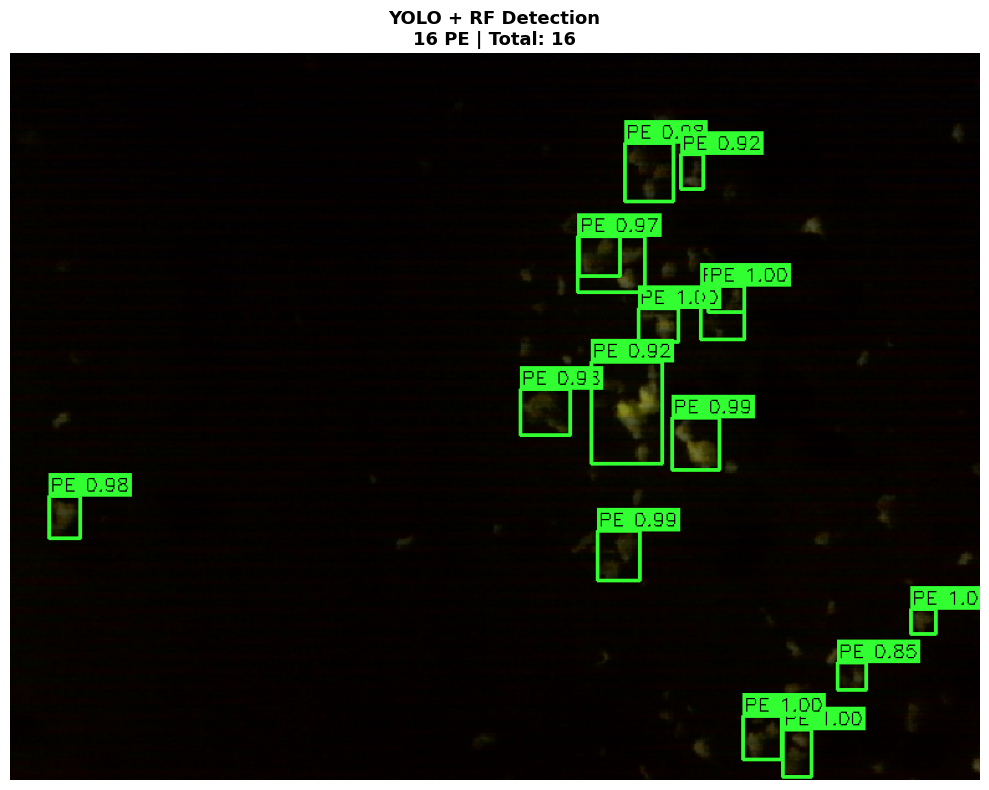


=== Detection Report ===
Total particles detected: 16
Per class: {'PE': 16}

Per particle breakdown:
RF_class  RF_conf  YOLO_conf
      PE     0.99      0.983
      PE     0.98      0.954
      PE     1.00      0.924
      PE     0.99      0.897
      PE     1.00      0.894
      PE     1.00      0.871
      PE     0.92      0.811
      PE     0.98      0.793
      PE     0.97      0.698
      PE     0.97      0.637
      PE     1.00      0.586
      PE     0.98      0.549
      PE     1.00      0.390
      PE     0.92      0.326
      PE     0.85      0.294
      PE     1.00      0.263


In [ ]:
from google.colab import files

uploaded = files.upload()
test_image_path = list(uploaded.keys())[0]
print(f"✅ Uploaded: {test_image_path}")

output_img, counts, log = run_final_pipeline(test_image_path)

plt.figure(figsize=(14, 8))
plt.imshow(output_img)
plt.axis('off')
summary = ', '.join([f"{v} {k}" for k,v in counts.items()])
plt.title(f'YOLO + RF Detection\n{summary} | Total: {sum(counts.values())}',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Detection Report ===")
print(f"Total particles detected: {sum(counts.values())}")
print(f"Per class: {counts}")
if len(log) > 0:
    print(f"\nPer particle breakdown:")
    print(log.to_string(index=False))

In [ ]:
import joblib
from google.colab import files

# Save everything needed to run RF later
joblib.dump({
    'model':         rf_crop,
    'scaler':        scaler,
    'label_encoder': le_crop,
    'feature_cols':  list(excel_feature_cols)
}, '/content/rf_microplastics.joblib')

print("✅ RF model saved!")
print(f"   Classes: {le_crop.classes_}")
print(f"   Features: {len(excel_feature_cols)}")

# Download
files.download('/content/rf_microplastics.joblib')

✅ RF model saved!
   Classes: ['ABS' 'Nylon' 'PE' 'PET' 'PS' 'PVC']
   Features: 36


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO
from google.colab import files

best_model = YOLO('/content/runs/detect/microplastics_yolo/weights/best.pt')

# Export to ONNX (lightweight for Pi/website deployment)
best_model.export(
    format='onnx',
    imgsz=640,
    simplify=True,
    opset=12
)

print("✅ YOLO exported to ONNX!")
files.download('/content/runs/detect/microplastics_yolo/weights/best.onnx')
print("✅ Download started!")

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/microplastics_yolo/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 296ms
Prepared 4 packages in 7.19s
Installed 4 packages in 326ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.25.1
 + onnxslim==0.1.92

requirements: AutoUpdate success ✅ 8.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 12..

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!
